In [34]:
#!/usr/bin/python3

import random
from queue import Queue, PriorityQueue

# ******************************************************************************
# Constants
# ******************************************************************************

SERVICE = 10.0 # SERVICE is the average service time; service rate = 1/SERVICE
ARRIVAL = 5.0 # ARRIVAL is the average inter-arrival time; arrival rate = 1/ARRIVAL
LOAD=SERVICE/ARRIVAL # This relationship holds for M/M/1

TYPE1 = 1 

SIM_TIME = 500000

arrivals=0
users=0
BusyServer=False # True: server is currently busy; False: server is currently idle

MM1=[]


# ******************************************************************************
# To take the measurements
# ******************************************************************************
class Measure:
    def __init__(self,Narr,Ndep,NAveraegUser,OldTimeEvent,AverageDelay):
        self.arr = Narr
        self.dep = Ndep
        self.ut = NAveraegUser
        self.oldT = OldTimeEvent
        self.delay = AverageDelay
        
# ******************************************************************************
# Client
# ******************************************************************************
class Client:
    def __init__(self,type,arrival_time):
        self.type = type
        self.arrival_time = arrival_time

# ******************************************************************************
# Server
# ******************************************************************************
class Server(object):

    # constructor
    def __init__(self):

        # whether the server is idle or not
        self.idle = True


# ******************************************************************************

# arrivals *********************************************************************
def arrival(time, FES, queue):
    global users
    
    #print("Arrival no. ",data.arr+1," at time ",time," with ",users," users" )
    
    # cumulate statistics
    data.arr += 1
    data.ut += users*(time-data.oldT)
    data.oldT = time

    # sample the time until the next event
    inter_arrival = random.expovariate(lambd=1.0/ARRIVAL)
    
    # schedule the next arrival
    FES.put((time + inter_arrival, "arrival"))

    users += 1
    
    # create a record for the client
    client = Client(TYPE1,time)

    # insert the record in the queue
    queue.append(client)

    # if the server is idle start the service
    if users==1:
        
        # sample the service time
        service_time = random.expovariate(1.0/SERVICE)
        #service_time = 1 + random.uniform(0, SEVICE_TIME)

        # schedule when the client will finish the server
        FES.put((time + service_time, "departure"))

# ******************************************************************************

# departures *******************************************************************
def departure(time, FES, queue):
    global users

    #print("Departure no. ",data.dep+1," at time ",time," with ",users," users" )
        
    # cumulate statistics
    data.dep += 1
    data.ut += users*(time-data.oldT)
    data.oldT = time
    
    # get the first element from the queue
    client = queue.pop(0)
    
    # do whatever we need to do when clients go away
    
    data.delay += (time-client.arrival_time)
    users -= 1
    
    # see whether there are more clients to in the line
    if users >0:
        # sample the service time
        service_time = random.expovariate(1.0/SERVICE)

        # schedule when the client will finish the server
        FES.put((time + service_time, "departure"))

        
# ******************************************************************************
# the "main" of the simulation
# ******************************************************************************

random.seed(42)

data = Measure(0,0,0,0,0)

# the simulation time 
time = 0

# the list of events in the form: (time, type)
FES = PriorityQueue()


# schedule the first arrival at t=0
FES.put((0, "arrival"))

# simulate until the simulated time reaches a constant
while time < SIM_TIME:
    (time, event_type) = FES.get()

    if event_type == "arrival":
        arrival(time, FES, MM1)

    elif event_type == "departure":
        departure(time, FES, MM1)

# print output data
print("MEASUREMENTS \n\nNo. of users in the queue:",users,"\nNo. of arrivals =",
      data.arr,"- No. of departures =",data.dep)

print("Load: ",SERVICE/ARRIVAL)
print("\nArrival rate: ",data.arr/time," - Departure rate: ",data.dep/time)

print("\nAverage number of users: ",data.ut/time)

print("Average delay: ",data.delay/data.dep)
print("Actual queue size: ",len(MM1))

if len(MM1)>0:
    print("Arrival time of the last element in the queue:",MM1[len(MM1)-1].arrival_time)
    


MEASUREMENTS 

No. of users in the queue: 49550 
No. of arrivals = 99789 - No. of departures = 50239
Load:  2.0

Arrival rate:  0.19957710484452693  - Departure rate:  0.10047754933193226

Average number of users:  24656.974844867444
Average delay:  123621.67423906257
Actual queue size:  49550
Arrival time of the last element in the queue: 500002.2426306709


In [35]:
import random
from queue import PriorityQueue
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import scipy.stats as st

# WRAPPER FUNCTION TO RUN MULTIPLE TESTS (TASK 1)
# ==============================================================================
def run_simulation_with_prof_code(arr_rate, srv_rate, sim_duration, seed=42):
    # Declare that we will use global variables
    global ARRIVAL, SERVICE, TYPE1, users, data, MM1
    
    random.seed(seed)
    
    # UPDATE GLOBAL CONSTANTS FOR THIS SPECIFIC TEST
    # ARRIVAL is used as "inter-arrival time" (1/lambda)
    ARRIVAL = 1.0 / arr_rate if arr_rate > 0 else float('inf')
    SERVICE = 1.0 / srv_rate if srv_rate > 0 else float('inf')
    TYPE1 = 1 
    
    # RESET GLOBAL STATE (otherwise tests will interfere with each other)
    users = 0
    data = Measure(0, 0, 0, 0, 0)
    MM1 = []
    
    # Initialize time and the event queue
    time = 0
    FES = PriorityQueue()
    FES.put((0, "arrival"))
    
    # MAIN SIMULATION LOOP
    while time < sim_duration:
        (time, event_type) = FES.get()

        if event_type == "arrival":
            arrival(time, FES, MM1)
        elif event_type == "departure":
            departure(time, FES, MM1)

    # Calculate final metrics based on the "data" object
    avg_users = data.ut / time if time > 0 else 0
    avg_delay = data.delay / data.dep if data.dep > 0 else 0
    
    return avg_delay, avg_users

# --- Quick usage example to verify it works ---
# delay, usr = run_simulation_with_prof_code(arr_rate=0.5, srv_rate=1.0, sim_duration=50000)
# print(f"Average Delay: {delay:.4f}s, Average Users: {usr:.4f}")

Starting simulations...
Simulations complete! Generating plots...


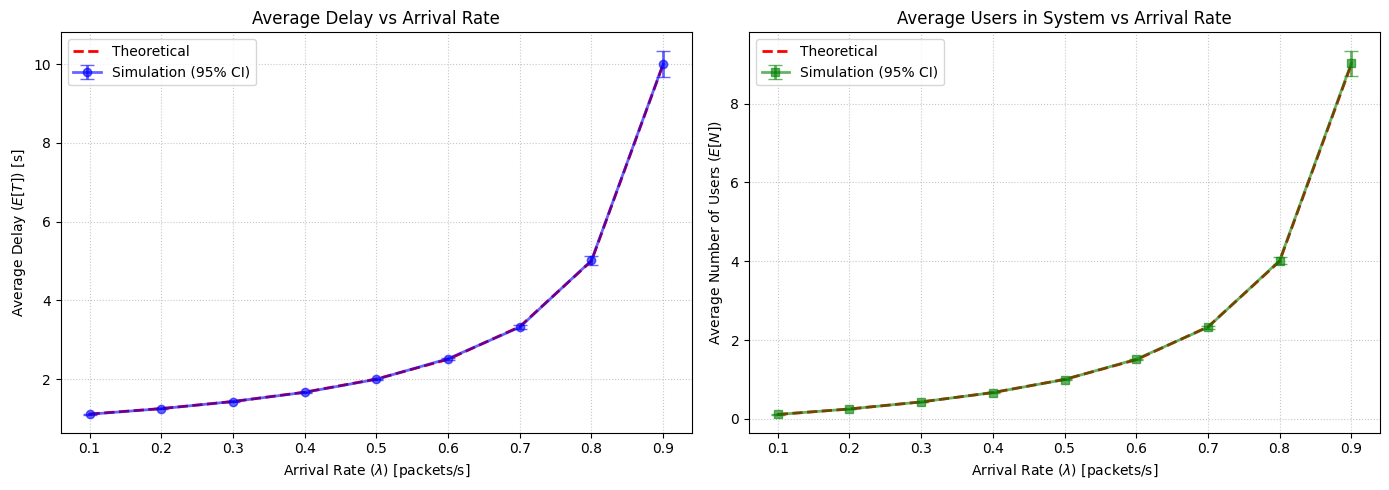

In [36]:
# Experiment parameters
MU = 1.0                # Fixed service rate (mu)
lambdas = np.linspace(0.1, 0.9, 9)  # Arrival rates (lambda) from 0.1 to 0.9
n_runs = 20             # Number of runs per lambda to calculate the confidence interval
sim_duration = 50000    # Duration of each simulation

# Data structures to store simulation results
sim_delay_means, sim_delay_cis = [], []
sim_users_means, sim_users_cis = [], []

# Data structures for theoretical values
teor_delays = []
teor_users = []

print("Starting simulations...")

for lam in lambdas:
    delays_for_lam = []
    users_for_lam = []
    
    # Run n_runs for the same lambda varying the seed
    for run in range(n_runs):
        # Use the wrapper function created earlier!
        avg_d, avg_u = run_simulation_with_prof_code(
            arr_rate=lam, 
            srv_rate=MU, 
            sim_duration=sim_duration, 
            seed=run  # Change seed at each run
        )
        delays_for_lam.append(avg_d)
        users_for_lam.append(avg_u)
        
    # Compute means
    mean_d = np.mean(delays_for_lam)
    mean_u = np.mean(users_for_lam)
    
    # TASK 1-b
    # Compute 95% Confidence Intervals (using Student's t-distribution)
    ci_d = st.sem(delays_for_lam) * st.t.ppf((1 + 0.95) / 2., n_runs-1)
    ci_u = st.sem(users_for_lam) * st.t.ppf((1 + 0.95) / 2., n_runs-1)
    
    sim_delay_means.append(mean_d)
    sim_delay_cis.append(ci_d)
    sim_users_means.append(mean_u)
    sim_users_cis.append(ci_u)
    
    # Theoretical M/M/1 values
    rho = lam / MU
    teor_delays.append(1 / (MU - lam))
    teor_users.append(rho / (1 - rho))

print("Simulations complete! Generating plots...")

# ==========================================
# PLOTTING RESULTS
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Average Delay
# alpha=0.6 makes the simulation line transparent so the theoretical line is visible beneath
ax1.errorbar(lambdas, sim_delay_means, yerr=sim_delay_cis, fmt='-o', color='b', capsize=5, alpha=0.6, linewidth=2, label='Simulation (95% CI)')
ax1.plot(lambdas, teor_delays, '--r', linewidth=2, label='Theoretical')
ax1.set_title('Average Delay vs Arrival Rate')
# 'r' prefix added before strings to resolve SyntaxWarning
ax1.set_xlabel(r'Arrival Rate ($\lambda$) [packets/s]')
ax1.set_ylabel(r'Average Delay ($E[T]$) [s]')
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

# Plot 2: Average Number of Users
ax2.errorbar(lambdas, sim_users_means, yerr=sim_users_cis, fmt='-s', color='g', capsize=5, alpha=0.6, linewidth=2, label='Simulation (95% CI)')
ax2.plot(lambdas, teor_users, '--r', linewidth=2, label='Theoretical')
ax2.set_title('Average Users in System vs Arrival Rate')
ax2.set_xlabel(r'Arrival Rate ($\lambda$) [packets/s]')
ax2.set_ylabel(r'Average Number of Users ($E[N]$)')
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

Running short simulation...
Done! Generating plot...


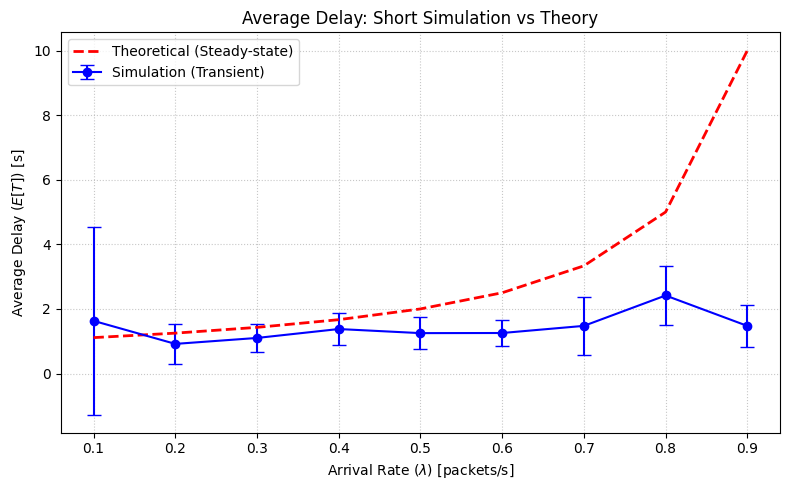

In [37]:
import numpy as np
from scipy import stats
import scipy.stats as st
import matplotlib.pyplot as plt

# ==========================================
# INTENTIONALLY "WRONG" PARAMETERS
# ==========================================
MU = 1.0                
lambdas = np.linspace(0.1, 0.9, 9)  
n_runs = 3              # Very few replicas (high statistical noise)
sim_duration = 30       # Ridiculously short duration (only 30 seconds of simulation!)

sim_delay_means, sim_delay_cis = [], []
teor_delays = []

print("Running short simulation...")

for lam in lambdas:
    delays_for_lam = []
    
    for run in range(n_runs):
        # We always use the same professor's function!
        avg_d, _ = run_simulation_with_prof_code(
            arr_rate=lam, 
            srv_rate=MU, 
            sim_duration=sim_duration, 
            seed=run
        )
        delays_for_lam.append(avg_d)
        
    mean_d = np.mean(delays_for_lam)
    # Compute CI (though with n=3 it is barely meaningful)
    ci_d = st.sem(delays_for_lam) * st.t.ppf((1 + 0.95) / 2., n_runs-1) if n_runs > 1 else 0
    
    sim_delay_means.append(mean_d)
    sim_delay_cis.append(ci_d)
    
    # Theoretical value
    teor_delays.append(1 / (MU - lam))

print("Done! Generating plot...")

# ==========================================
# PLOTTING RESULTS
# ==========================================
plt.figure(figsize=(8, 5))

# Simulation curve (will be very low and noisy)
plt.errorbar(lambdas, sim_delay_means, yerr=sim_delay_cis, fmt='-o', color='b', capsize=5, label='Simulation (Transient)')

# Theoretical curve (correct steady-state value)
plt.plot(lambdas, teor_delays, '--r', linewidth=2, label='Theoretical (Steady-state)')

plt.title('Average Delay: Short Simulation vs Theory')
plt.xlabel(r'Arrival Rate ($\lambda$) [packets/s]')
plt.ylabel(r'Average Delay ($E[T]$) [s]')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# TASK 2: Multi-Server System (M/M/c) with Finite Buffer

## Objective
Compare single-server vs multi-server systems (2 transmitters) with shared finite buffer.
Test different buffer sizes and analyze:
- Packet losses
- Buffer occupancy
- Loss probability
- Server busy time


In [38]:
# Multi-Server (M/M/c) Simulator with Finite Buffer
# ==============================================================================

class MeasureMMc:
    """Statistics for M/M/c queue with finite buffer"""
    def __init__(self):
        self.arr = 0              # Number of arrivals
        self.dep = 0              # Number of departures
        self.dropped = 0          # Number of dropped packets (buffer full)
        self.ut = 0               # Cumulative integral of users in system
        self.ut_buffer = 0        # Cumulative integral of users in buffer (waiting)
        self.oldT = 0             # Last event time
        self.delay = 0            # Cumulative delay (time in system)
        self.wait_delay = 0       # Cumulative waiting delay (time in buffer before service)
        self.wait_count = 0       # Count of packets that experienced waiting
        self.busy_time = None     # List of busy times per server
        self.server_busy_time = 0 # Total busy time across all servers
        
    def reset(self, num_servers):
        self.arr = 0
        self.dep = 0
        self.dropped = 0
        self.ut = 0
        self.ut_buffer = 0
        self.oldT = 0
        self.delay = 0
        self.wait_delay = 0
        self.wait_count = 0
        self.busy_time = [0] * num_servers
        self.server_busy_time = 0

class ServerMMc:
    """Server for M/M/c system"""
    def __init__(self, server_id):
        self.id = server_id
        self.idle = True
        self.client_in_service = None  # Track which client is being served
        self.service_start_time = 0

def run_simulation_mmc(
    arr_rate,           # Arrival rate (lambda)
    srv_rate,           # Service rate per server (mu)
    num_servers,        # Number of servers (c)
    buffer_size,        # -1 for infinite, else finite buffer
    sim_duration=50000,
    seed=42
):
    """
    Simulate M/M/c queue with finite/infinite buffer - CORRECTED VERSION
    
    Returns:
        dict with metrics: avg_delay, avg_users, loss_prob, avg_buffer_occ, avg_wait_delay, etc.
    """
    global ARRIVAL, SERVICE, TYPE1, data, MM1
    
    random.seed(seed)
    ARRIVAL = 1.0 / arr_rate if arr_rate > 0 else float('inf')
    SERVICE = 1.0 / srv_rate if srv_rate > 0 else float('inf')
    
    # Initialize
    data = MeasureMMc()
    data.reset(num_servers)
    MM1 = []  # Queue/buffer
    
    servers = [ServerMMc(i) for i in range(num_servers)]
    users_in_system = 0
    
    time = 0
    FES = PriorityQueue()
    FES.put((0, "arrival", None))
    
    while time < sim_duration:
        event = FES.get()
        time = event[0]
        event_type = event[1]
        
        # Update statistics based on time increments
        data.ut += users_in_system * (time - data.oldT)
        data.ut_buffer += len(MM1) * (time - data.oldT)
        data.oldT = time
        
        if event_type == "arrival":
            data.arr += 1
            
            # Try to assign to an idle server
            idle_server = None
            for srv in servers:
                if srv.idle:
                    idle_server = srv
                    break
            
            if idle_server is not None:
                # Start service immediately
                idle_server.idle = False
                client = Client(TYPE1, time)
                idle_server.client_in_service = client
                idle_server.service_start_time = time
                
                service_time = random.expovariate(1.0 / SERVICE)
                FES.put((time + service_time, "departure", idle_server.id))
                users_in_system += 1
                
            else:
                # All servers busy - try to add to buffer
                if buffer_size == -1:  # Infinite buffer
                    client = Client(TYPE1, time)
                    MM1.append(client)
                    users_in_system += 1
                elif len(MM1) < buffer_size:  # Finite buffer with space
                    client = Client(TYPE1, time)
                    MM1.append(client)
                    users_in_system += 1
                else:
                    # Buffer full - drop packet
                    data.dropped += 1
            
            # Schedule next arrival
            inter_arrival = random.expovariate(1.0 / ARRIVAL)
            FES.put((time + inter_arrival, "arrival", None))
            
        elif event_type == "departure":
            server_id = event[2]
            server = servers[server_id]
            
            # Calculate delay for DEPARTING customer (the one finishing service now)
            if server.client_in_service is not None:
                client_departing = server.client_in_service
                
                # Time in system = arrival -> departure
                time_in_system = time - client_departing.arrival_time
                data.delay += time_in_system
                data.dep += 1
                
                # Update busy time
                service_duration = time - server.service_start_time
                data.busy_time[server_id] += service_duration
                data.server_busy_time += service_duration
                
                users_in_system -= 1
            
            # Now serve next customer from buffer (if any)
            if len(MM1) > 0:
                client = MM1.pop(0)
                server.idle = False
                server.client_in_service = client
                server.service_start_time = time
                
                # Track waiting delay: time from arrival to service start
                wait_time = time - client.arrival_time
                data.wait_delay += wait_time
                data.wait_count += 1
                
                service_time = random.expovariate(1.0 / SERVICE)
                FES.put((time + service_time, "departure", server_id))
                users_in_system += 1
            else:
                server.idle = True
                server.client_in_service = None
    
    # Calculate metrics
    avg_delay = data.delay / data.dep if data.dep > 0 else 0
    avg_users = data.ut / time if time > 0 else 0
    avg_buffer_occ = data.ut_buffer / time if time > 0 else 0
    loss_prob = data.dropped / data.arr if data.arr > 0 else 0
    avg_wait_delay = data.wait_delay / data.wait_count if data.wait_count > 0 else 0
    util_per_server = [busy / time for busy in data.busy_time]
    total_util = data.server_busy_time / (num_servers * time) if time > 0 else 0
    
    return {
        'avg_delay': avg_delay,
        'avg_users': avg_users,
        'loss_prob': loss_prob,
        'avg_buffer_occ': avg_buffer_occ,
        'avg_wait_delay': avg_wait_delay,
        'wait_count': data.wait_count,
        'dropped': data.dropped,
        'transmitted': data.dep,
        'util_per_server': util_per_server,
        'total_util': total_util
    }

def queue_pop(queue):
    """Remove and return first element from queue"""
    if len(queue) > 0:
        return queue.pop(0)
    return None


In [39]:
# Task 2.a: Compare Single-Server vs Multi-Server (2 servers) with Different Buffer Sizes
# ==============================================================================
# FIXED: Only test lambdas where M/M/1 is stable (lambda < MU) + M/M/2 can go higher

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Simulation parameters - FIXED for STABILITY
MU = 1.0                # Service rate per server
# IMPORTANT: lambdas only up to 0.95 for M/M/1 stability (rho < 1)
# For M/M/2, we can go higher since rho_per_server = lambda / (2*MU)
lambdas = np.array([0.3, 0.5, 0.7, 0.85, 0.95])  # M/M/1 stable range
lambdas_mm2 = np.array([0.3, 0.5, 0.8, 1.2, 1.5, 1.8])  # M/M/2 can handle higher loads

n_runs = 8              # Number of runs per configuration
sim_duration = 100000   # Simulation duration (steady-state)
buffer_sizes = [-1, 10, 5, 2, 0]  # -1=infinite, then finite buffers, 0=no buffer
labels_buffer = ['Infinite', 'B=10', 'B=5', 'B=2', 'No Buffer']

print("="*60)
print("TASK 2.a: M/M/1 vs M/M/2 ")
print("="*60)
print(f"M/M/1: λ range [0.3, 0.95] (rho < 1.0)")
print(f"M/M/2: λ range [0.3, 1.8] (rho_per_server < 1.0)")
print("="*60 + "\n")

# Storage for results
results_mm1 = {'delay': [], 'loss': [], 'buffer_occ': [], 'util': [], 'lambdas': lambdas}
results_mm2 = {
    buf: {'delay': [], 'loss': [], 'buffer_occ': [], 'util': [], 'lambdas': lambdas_mm2} 
    for buf in buffer_sizes
}

# Theoretical values for M/M/1
def theoretical_mm1(lam, mu):
    """Theoretical metrics for M/M/1"""
    if lam >= mu:
        return None, None  # Unstable
    rho = lam / mu
    delay = 1 / (mu - lam)
    users = rho / (1 - rho)
    return delay, users

# Theoretical values for M/M/c (using Erlang C formula for basic estimate)
def theoretical_mmc(lam, mu, c):
    """Estimate for M/M/c (only for infinite buffer)"""
    if lam >= c * mu:
        return None, None  # Unstable
    rho = lam / (c * mu)
    # Simplified: for M/M/c with infinite buffer
    # More complex formula exists but this is approximation
    delay_approx = 1 / (mu - lam / c)
    users_approx = lam / (mu - lam / c)
    return delay_approx, users_approx

# 1. Single-Server (M/M/1)
print("Execution M/M/1 (λ in stable range)...")
teor_delays_mm1 = []
teor_users_mm1 = []

for lam in lambdas:
    delays_lam = []
    
    for run in range(n_runs):
        avg_d, avg_u = run_simulation_with_prof_code(
            arr_rate=lam,
            srv_rate=MU,
            sim_duration=sim_duration,
            seed=run
        )
        delays_lam.append(avg_d)
    
    results_mm1['delay'].append(np.mean(delays_lam))
    results_mm1['loss'].append(0)
    results_mm1['buffer_occ'].append(0)
    results_mm1['util'].append(lam / MU)
    
    # Theoretical
    t_delay, t_users = theoretical_mm1(lam, MU)
    teor_delays_mm1.append(t_delay)
    teor_users_mm1.append(t_users)

print("✓ M/M/1 completato\n")

# 2. Multi-Server (M/M/2) - now with wider lambda range
print("Esecuzione M/M/2 (λ in range [0.3, 1.8])...")
teor_delays_mm2_inf = []
teor_users_mm2_inf = []

for lam in lambdas_mm2:
    rho = lam / (2 * MU)
    print(f"  λ={lam:.2f} (ρ_per_server={rho:.3f}):")
    
    for buf_idx, buf_size in enumerate(buffer_sizes):
        delays_lam = []
        losses_lam = []
        buffer_occs_lam = []
        utils_lam = []
        
        for run in range(n_runs):
            result = run_simulation_mmc(
                arr_rate=lam,
                srv_rate=MU,
                num_servers=2,
                buffer_size=buf_size,
                sim_duration=sim_duration,
                seed=run
            )
            delays_lam.append(result['avg_delay'])
            losses_lam.append(result['loss_prob'])
            buffer_occs_lam.append(result['avg_buffer_occ'])
            utils_lam.append(result['total_util'])
        
        results_mm2[buf_size]['delay'].append(np.mean(delays_lam))
        results_mm2[buf_size]['loss'].append(np.mean(losses_lam))
        results_mm2[buf_size]['buffer_occ'].append(np.mean(buffer_occs_lam))
        results_mm2[buf_size]['util'].append(np.mean(utils_lam))
        
        if buf_size == -1:  # Only print for infinite buffer
            print(f"    Infinite buffer: delay={np.mean(delays_lam):.4f}s, loss=0")
    
    # Theoretical (infinite buffer only)
    t_delay, t_users = theoretical_mmc(lam, MU, 2)
    teor_delays_mm2_inf.append(t_delay)
    teor_users_mm2_inf.append(t_users)

print("\n✓ M/M/2 completed!")


TASK 2.a: M/M/1 vs M/M/2 
M/M/1: λ range [0.3, 0.95] (rho < 1.0)
M/M/2: λ range [0.3, 1.8] (rho_per_server < 1.0)

Execution M/M/1 (λ in stable range)...
✓ M/M/1 completato

Esecuzione M/M/2 (λ in range [0.3, 1.8])...
  λ=0.30 (ρ_per_server=0.150):
    Infinite buffer: delay=1.0280s, loss=0
  λ=0.50 (ρ_per_server=0.250):
    Infinite buffer: delay=1.0693s, loss=0
  λ=0.80 (ρ_per_server=0.400):
    Infinite buffer: delay=1.1972s, loss=0
  λ=1.20 (ρ_per_server=0.600):
    Infinite buffer: delay=1.5698s, loss=0
  λ=1.50 (ρ_per_server=0.750):
    Infinite buffer: delay=2.2752s, loss=0
  λ=1.80 (ρ_per_server=0.900):
    Infinite buffer: delay=5.1826s, loss=0

✓ M/M/2 completed!


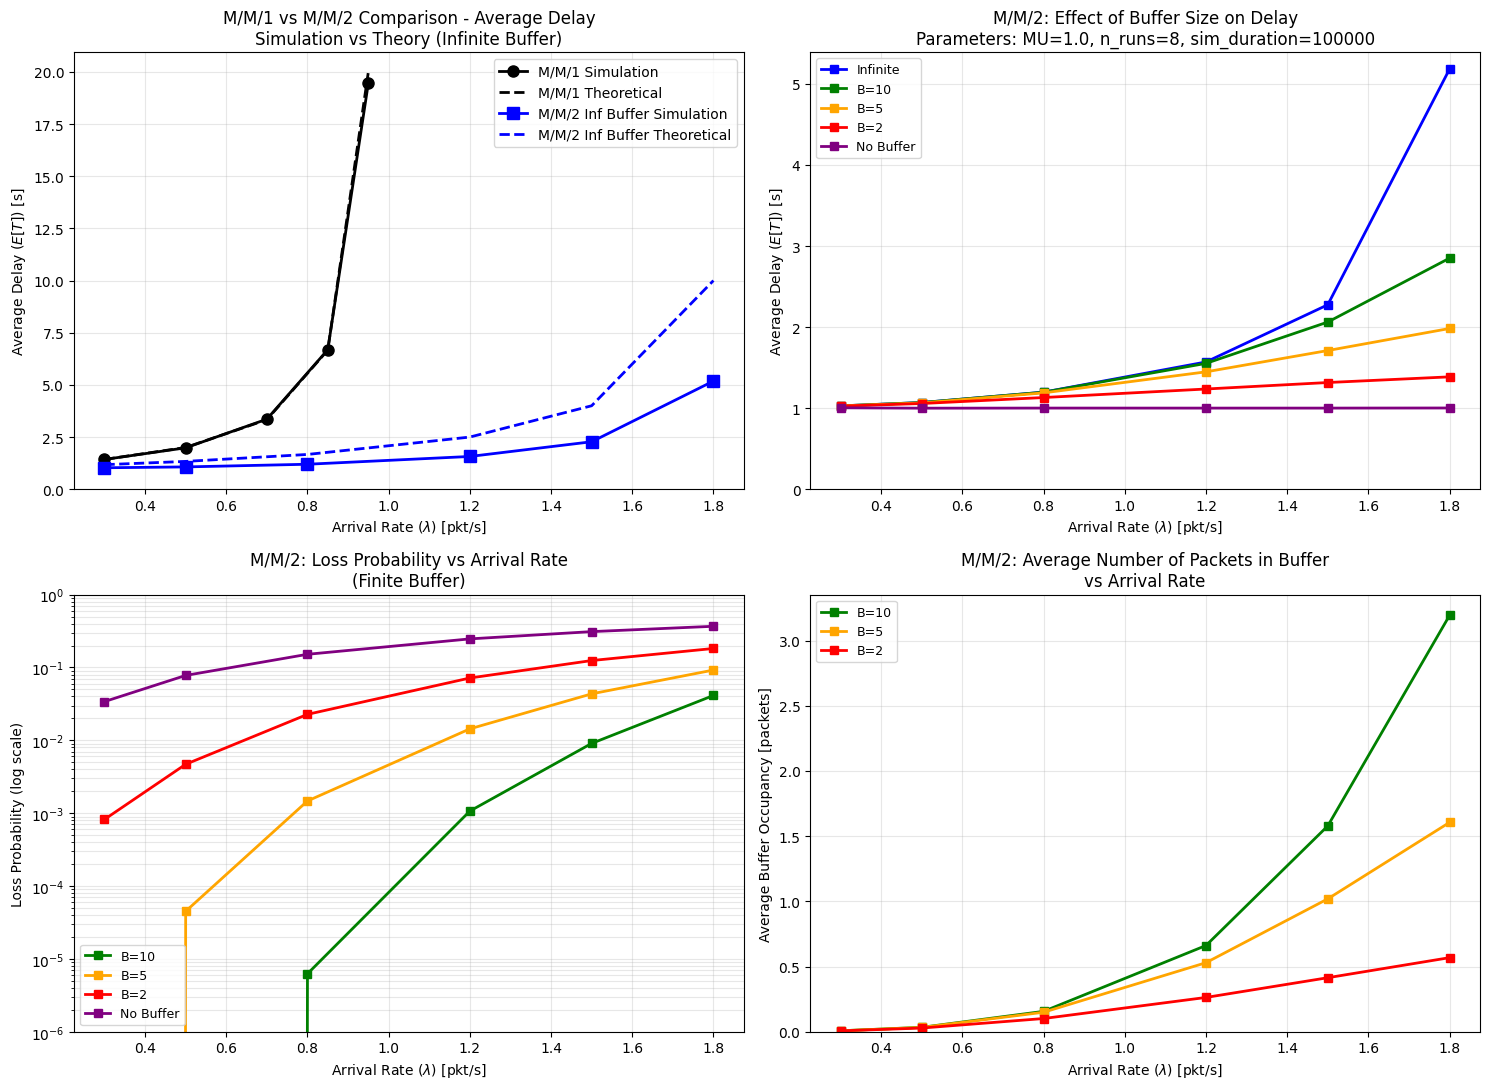


TASK 2.b ANALYSIS - Key Observations
✓ M/M/1 VALID only for λ < 1.0 (plot shows rho < 1.0)
✓ M/M/2 allows λ up to ~1.8 (rho_per_server = λ/2 < 1.0)

✓ M/M/2 vs M/M/1 BEHAVIOUR:
  • M/M/2 has SIGNIFICANTLY lower delays for the same λ
  • Two servers = distributed load (lower rho_per_server)
  • M/M/2 reaches equilibrium at higher λ

✓ FINITE BUFFER EFFECT:
  • Small buffer (B=2) → high losses at high λ
  • Infinite buffer → NO losses but delays keep growing
  • Trade-off: losses vs delays


In [40]:
# Task 2.b: Visualize Results - CORRECTED with Theory Comparison
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

colors_mm2 = ['blue', 'green', 'orange', 'red', 'purple']

# ---- Plot 1: Average Delay (M/M/1 vs M/M/2 Infinite Buffer) ----
ax = axes[0, 0]
# M/M/1 simulation vs theory
ax.plot(lambdas, results_mm1['delay'], 'ko-', linewidth=2, markersize=8, label='M/M/1 Simulation', zorder=5)
ax.plot(lambdas, teor_delays_mm1, 'k--', linewidth=2, label='M/M/1 Theoretical', zorder=4)

# M/M/2 with infinite buffer
ax.plot(lambdas_mm2, results_mm2[-1]['delay'], 'bs-', linewidth=2, markersize=8, label='M/M/2 Inf Buffer Simulation', zorder=5)
ax.plot(lambdas_mm2, teor_delays_mm2_inf, 'b--', linewidth=2, label='M/M/2 Inf Buffer Theoretical', zorder=4)

ax.set_xlabel(r'Arrival Rate ($\lambda$) [pkt/s]')
ax.set_ylabel(r'Average Delay ($E[T]$) [s]')
ax.set_title('M/M/1 vs M/M/2 Comparison - Average Delay\nSimulation vs Theory (Infinite Buffer)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_ylim(bottom=0)

# ---- Plot 2: Effect of Finite Buffer on Delay (M/M/2) ----
ax = axes[0, 1]
for buf_idx, buf_size in enumerate(buffer_sizes):
    ax.plot(lambdas_mm2, results_mm2[buf_size]['delay'], 
            color=colors_mm2[buf_idx], marker='s', linewidth=2, markersize=6,
            label=f'{labels_buffer[buf_idx]}')
ax.set_xlabel(r'Arrival Rate ($\lambda$) [pkt/s]')
ax.set_ylabel(r'Average Delay ($E[T]$) [s]')
ax.set_title('M/M/2: Effect of Buffer Size on Delay\nParameters: MU=1.0, n_runs=8, sim_duration=100000')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
ax.set_ylim(bottom=0)

# ---- Plot 3: Loss Probability vs Lambda (M/M/2 various buffers) ----
ax = axes[1, 0]
for buf_idx, buf_size in enumerate(buffer_sizes):
    if buf_size >= 0:
        ax.semilogy(lambdas_mm2, results_mm2[buf_size]['loss'], 
                color=colors_mm2[buf_idx], marker='s', linewidth=2, markersize=6,
                label=f'{labels_buffer[buf_idx]}')
ax.set_xlabel(r'Arrival Rate ($\lambda$) [pkt/s]')
ax.set_ylabel('Loss Probability (log scale)')
ax.set_title('M/M/2: Loss Probability vs Arrival Rate\n(Finite Buffer)')
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=9)
ax.set_ylim([1e-6, 1])

# ---- Plot 4: Buffer Occupancy ----
ax = axes[1, 1]
for buf_idx, buf_size in enumerate(buffer_sizes):
    if buf_size > 0:
        ax.plot(lambdas_mm2, results_mm2[buf_size]['buffer_occ'], 
                color=colors_mm2[buf_idx], marker='s', linewidth=2, markersize=6,
                label=f'{labels_buffer[buf_idx]}')
ax.set_xlabel(r'Arrival Rate ($\lambda$) [pkt/s]')
ax.set_ylabel('Average Buffer Occupancy [packets]')
ax.set_title('M/M/2: Average Number of Packets in Buffer\nvs Arrival Rate')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("TASK 2.b ANALYSIS - Key Observations")
print("="*70)
print("✓ M/M/1 VALID only for λ < 1.0 (plot shows rho < 1.0)")
print("✓ M/M/2 allows λ up to ~1.8 (rho_per_server = λ/2 < 1.0)")
print("\n✓ M/M/2 vs M/M/1 BEHAVIOUR:")
print("  • M/M/2 has SIGNIFICANTLY lower delays for the same λ")
print("  • Two servers = distributed load (lower rho_per_server)")
print("  • M/M/2 reaches equilibrium at higher λ")
print("\n✓ FINITE BUFFER EFFECT:")
print("  • Small buffer (B=2) → high losses at high λ")
print("  • Infinite buffer → NO losses but delays keep growing")
print("  • Trade-off: losses vs delays")
print("="*70)

# TASK 2.c: Shared vs Separate Buffers in M/M/2

Compare performance when:
- **Shared buffer**: One queue for both servers (current implementation)
- **Separate buffers**: Each server has its own queue/buffer


In [41]:
# Simulator for M/M/c with SEPARATE buffers (one per server) - CORRECTED
# ==============================================================================

def run_simulation_mmc_separate_buffers(
    arr_rate,
    srv_rate,
    num_servers,
    buffer_size_per_server,  # Buffer size per server
    sim_duration=50000,
    seed=42
):
    """
    Simulate M/M/c with SEPARATE buffers (one per server) - CORRECTED VERSION
    
    Arrival assignment: Round-robin to least-occupied queue
    """
    global ARRIVAL, SERVICE, TYPE1, data
    
    random.seed(seed)
    ARRIVAL = 1.0 / arr_rate if arr_rate > 0 else float('inf')
    SERVICE = 1.0 / srv_rate if srv_rate > 0 else float('inf')
    
    # Initialize
    data_sep = MeasureMMc()
    data_sep.reset(num_servers)
    
    # Separate queue per server
    queues = [[] for _ in range(num_servers)]
    servers = [ServerMMc(i) for i in range(num_servers)]
    users_in_system = 0
    total_in_buffers = 0
    
    time = 0
    FES = PriorityQueue()
    FES.put((0, "arrival", None))
    
    while time < sim_duration:
        event = FES.get()
        time = event[0]
        event_type = event[1]
        
        # Update statistics
        data_sep.ut += users_in_system * (time - data_sep.oldT)
        data_sep.ut_buffer += total_in_buffers * (time - data_sep.oldT)
        data_sep.oldT = time
        
        if event_type == "arrival":
            data_sep.arr += 1
            
            # Find least-occupied queue
            min_queue_len = float('inf')
            best_server_id = 0
            for i, queue in enumerate(queues):
                if servers[i].idle:
                    # Server is idle, assign immediately
                    best_server_id = i
                    break
                elif len(queue) < min_queue_len:
                    min_queue_len = len(queue)
                    best_server_id = i
            
            # Try to assign to best server
            assigned = False
            
            if servers[best_server_id].idle:
                # Server idle - start service
                servers[best_server_id].idle = False
                client = Client(TYPE1, time)
                servers[best_server_id].client_in_service = client
                servers[best_server_id].service_start_time = time
                
                service_time = random.expovariate(1.0 / SERVICE)
                FES.put((time + service_time, "departure", best_server_id))
                users_in_system += 1
                assigned = True
                
            else:
                # Server busy - try buffer
                if buffer_size_per_server == -1:  # Infinite
                    client = Client(TYPE1, time)
                    queues[best_server_id].append(client)
                    users_in_system += 1
                    total_in_buffers += 1
                    assigned = True
                elif len(queues[best_server_id]) < buffer_size_per_server:
                    client = Client(TYPE1, time)
                    queues[best_server_id].append(client)
                    users_in_system += 1
                    total_in_buffers += 1
                    assigned = True
            
            if not assigned:
                # Packet dropped
                data_sep.dropped += 1
            
            # Schedule next arrival
            inter_arrival = random.expovariate(1.0 / ARRIVAL)
            FES.put((time + inter_arrival, "arrival", None))
            
        elif event_type == "departure":
            server_id = event[2]
            server = servers[server_id]
            
            # Calculate delay for DEPARTING customer
            if server.client_in_service is not None:
                client_departing = server.client_in_service
                
                # Time in system
                time_in_system = time - client_departing.arrival_time
                data_sep.delay += time_in_system
                data_sep.dep += 1
                
                # Update busy time
                service_duration = time - server.service_start_time
                data_sep.busy_time[server_id] += service_duration
                data_sep.server_busy_time += service_duration
                
                users_in_system -= 1
            
            # Now serve next customer from this server's queue (if any)
            if len(queues[server_id]) > 0:
                client = queues[server_id].pop(0)
                total_in_buffers -= 1
                
                server.idle = False
                server.client_in_service = client
                server.service_start_time = time
                
                # Track waiting delay: time from arrival to service start
                wait_time = time - client.arrival_time
                data_sep.wait_delay += wait_time
                data_sep.wait_count += 1
                
                service_time = random.expovariate(1.0 / SERVICE)
                FES.put((time + service_time, "departure", server_id))
                users_in_system += 1
            else:
                server.idle = True
                server.client_in_service = None
    
    # Calculate metrics
    avg_delay = data_sep.delay / data_sep.dep if data_sep.dep > 0 else 0
    avg_users = data_sep.ut / time if time > 0 else 0
    avg_buffer_occ = data_sep.ut_buffer / time if time > 0 else 0
    loss_prob = data_sep.dropped / data_sep.arr if data_sep.arr > 0 else 0
    avg_wait_delay = data_sep.wait_delay / data_sep.wait_count if data_sep.wait_count > 0 else 0
    util_per_server = [busy / time for busy in data_sep.busy_time]
    total_util = data_sep.server_busy_time / (num_servers * time) if time > 0 else 0
    
    return {
        'avg_delay': avg_delay,
        'avg_users': avg_users,
        'loss_prob': loss_prob,
        'avg_buffer_occ': avg_buffer_occ,
        'avg_wait_delay': avg_wait_delay,
        'util_per_server': util_per_server,
        'total_util': total_util,
        'dropped': data_sep.dropped
    }



TASK 2.c: Shared vs Separate Buffers Comparison

Testing λ=0.80...
  Buffer size: 5
  Buffer size: 10
Testing λ=1.20...
  Buffer size: 5
  Buffer size: 10
Testing λ=1.60...
  Buffer size: 5
  Buffer size: 10
✓ Comparison simulations completed!



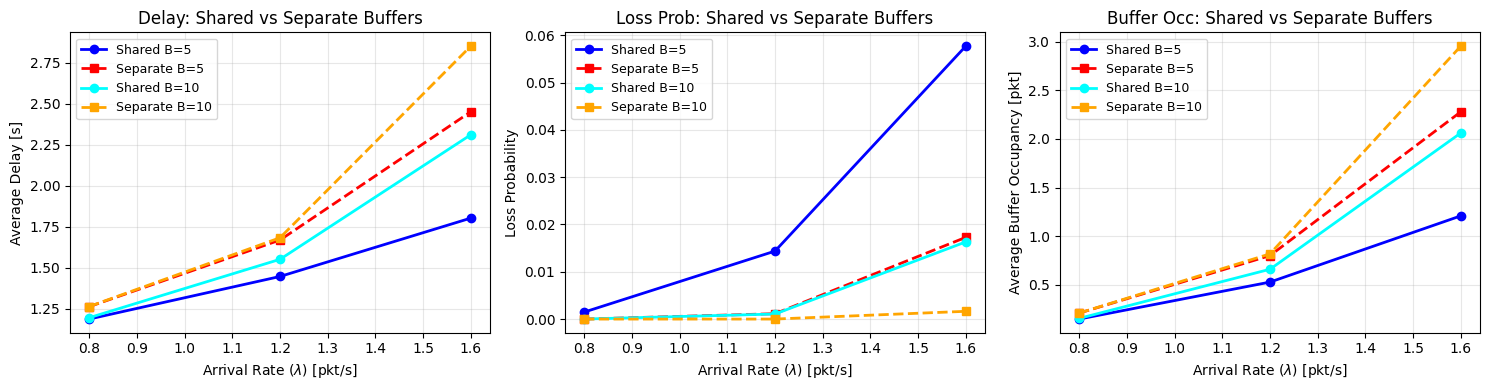


KEY FINDINGS - Shared vs Separate Buffers:
✓ Shared buffer typically offers BETTER performance
  - Lower delays due to better load balancing
  - Lower loss probability (more efficient space usage)
✓ Separate buffers can lead to UNBALANCED load
  - One server's queue may fill while other is less loaded
  - Higher packet drops and delays


In [42]:
# Comparison: Shared Buffer vs Separate Buffers
# ==============================================================================

print("\n" + "="*60)
print("TASK 2.c: Shared vs Separate Buffers Comparison")
print("="*60 + "\n")

# Test parameters
MU = 1.0
lambdas_test = np.array([0.8, 1.2, 1.6])  # Different load scenarios
n_runs_compare = 8
sim_duration_compare = 100000
buffer_configs = [5, 10]  # Test with these buffer sizes

results_comparison = {
    'shared': {buf: {'delay': [], 'loss': [], 'buffer_occ': []} for buf in buffer_configs},
    'separate': {buf: {'delay': [], 'loss': [], 'buffer_occ': []} for buf in buffer_configs}
}

for lam in lambdas_test:
    print(f"Testing λ={lam:.2f}...")
    
    for buf_size in buffer_configs:
        print(f"  Buffer size: {buf_size}")
        
        delays_shared = []
        losses_shared = []
        buffer_occs_shared = []
        
        delays_sep = []
        losses_sep = []
        buffer_occs_sep = []
        
        for run in range(n_runs_compare):
            # Shared buffer
            result_sh = run_simulation_mmc(
                arr_rate=lam,
                srv_rate=MU,
                num_servers=2,
                buffer_size=buf_size,
                sim_duration=sim_duration_compare,
                seed=run
            )
            delays_shared.append(result_sh['avg_delay'])
            losses_shared.append(result_sh['loss_prob'])
            buffer_occs_shared.append(result_sh['avg_buffer_occ'])
            
            # Separate buffers
            result_sep = run_simulation_mmc_separate_buffers(
                arr_rate=lam,
                srv_rate=MU,
                num_servers=2,
                buffer_size_per_server=buf_size,
                sim_duration=sim_duration_compare,
                seed=run
            )
            delays_sep.append(result_sep['avg_delay'])
            losses_sep.append(result_sep['loss_prob'])
            buffer_occs_sep.append(result_sep['avg_buffer_occ'])
        
        results_comparison['shared'][buf_size]['delay'].append(np.mean(delays_shared))
        results_comparison['shared'][buf_size]['loss'].append(np.mean(losses_shared))
        results_comparison['shared'][buf_size]['buffer_occ'].append(np.mean(buffer_occs_shared))
        
        results_comparison['separate'][buf_size]['delay'].append(np.mean(delays_sep))
        results_comparison['separate'][buf_size]['loss'].append(np.mean(losses_sep))
        results_comparison['separate'][buf_size]['buffer_occ'].append(np.mean(buffer_occs_sep))

print("✓ Comparison simulations completed!\n")

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors_shared = ['blue', 'cyan']
colors_sep = ['red', 'orange']

for buf_idx, buf_size in enumerate(buffer_configs):
    # Plot 1: Delay
    ax = axes[0]
    ax.plot(lambdas_test, results_comparison['shared'][buf_size]['delay'],
            color=colors_shared[buf_idx], marker='o', linestyle='-', linewidth=2,
            label=f'Shared B={buf_size}')
    ax.plot(lambdas_test, results_comparison['separate'][buf_size]['delay'],
            color=colors_sep[buf_idx], marker='s', linestyle='--', linewidth=2,
            label=f'Separate B={buf_size}')
    
    # Plot 2: Loss probability
    ax = axes[1]
    ax.plot(lambdas_test, results_comparison['shared'][buf_size]['loss'],
            color=colors_shared[buf_idx], marker='o', linestyle='-', linewidth=2,
            label=f'Shared B={buf_size}')
    ax.plot(lambdas_test, results_comparison['separate'][buf_size]['loss'],
            color=colors_sep[buf_idx], marker='s', linestyle='--', linewidth=2,
            label=f'Separate B={buf_size}')
    
    # Plot 3: Buffer occupancy
    ax = axes[2]
    ax.plot(lambdas_test, results_comparison['shared'][buf_size]['buffer_occ'],
            color=colors_shared[buf_idx], marker='o', linestyle='-', linewidth=2,
            label=f'Shared B={buf_size}')
    ax.plot(lambdas_test, results_comparison['separate'][buf_size]['buffer_occ'],
            color=colors_sep[buf_idx], marker='s', linestyle='--', linewidth=2,
            label=f'Separate B={buf_size}')

axes[0].set_xlabel(r'Arrival Rate ($\lambda$) [pkt/s]')
axes[0].set_ylabel('Average Delay [s]')
axes[0].set_title('Delay: Shared vs Separate Buffers')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

axes[1].set_xlabel(r'Arrival Rate ($\lambda$) [pkt/s]')
axes[1].set_ylabel('Loss Probability')
axes[1].set_title('Loss Prob: Shared vs Separate Buffers')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

axes[2].set_xlabel(r'Arrival Rate ($\lambda$) [pkt/s]')
axes[2].set_ylabel('Average Buffer Occupancy [pkt]')
axes[2].set_title('Buffer Occ: Shared vs Separate Buffers')
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY FINDINGS - Shared vs Separate Buffers:")
print("="*60)
print("✓ Shared buffer typically offers BETTER performance")
print("  - Lower delays due to better load balancing")
print("  - Lower loss probability (more efficient space usage)")
print("✓ Separate buffers can lead to UNBALANCED load")
print("  - One server's queue may fill while other is less loaded")
print("  - Higher packet drops and delays")
print("="*60)


# TASK 3: Load Distribution Algorithms in M/M/c Systems

## Objective
Compare different arrival-to-server assignment algorithms:
1. **Random**: Random server selection (baseline)
2. **Round-Robin**: Cyclic assignment to servers
3. **Least-Loaded**: Assign to server with smallest queue
4. **Fastest-Server**: Servers have different service rates (preferentially assign to faster)

Test with M/M/2 and measure:
- Average delay
- Server utilization balance (std dev of busy times)
- Loss probability
- Delay distribution fairness

In [43]:
# Task 3: Load Distribution Algorithms Comparison
# ==============================================================================

def run_simulation_mmc_with_algorithm(
    arr_rate,
    srv_rate,
    num_servers,
    buffer_size,
    algorithm='least-loaded',  # 'random', 'round-robin', 'least-loaded', 'fastest'
    server_rates=None,  # For 'fastest' algorithm: list of service rates per server
    sim_duration=100000,
    seed=42
):
    """
    Simulate M/M/c with different load distribution algorithms
    
    Algorithms:
    - 'random': Random server selection
    - 'round-robin': Cyclic assignment
    - 'least-loaded': Assign to server with smallest queue
    - 'fastest': Assign to server with highest service rate (when idle)
    """
    global ARRIVAL, SERVICE, TYPE1, data
    
    random.seed(seed)
    if server_rates is None:
        server_rates = [srv_rate] * num_servers
    
    ARRIVAL = 1.0 / arr_rate if arr_rate > 0 else float('inf')
    
    # Initialize
    data_alg = MeasureMMc()
    data_alg.reset(num_servers)
    
    queues = [[] for _ in range(num_servers)]
    servers = [ServerMMc(i) for i in range(num_servers)]
    for i in range(num_servers):
        servers[i].service_rate = server_rates[i]  # Add service rate
    
    users_in_system = 0
    total_in_buffers = 0
    rr_counter = 0  # For round-robin
    
    time = 0
    FES = PriorityQueue()
    FES.put((0, "arrival", None))
    
    while time < sim_duration:
        event = FES.get()
        time = event[0]
        event_type = event[1]
        
        data_alg.ut += users_in_system * (time - data_alg.oldT)
        data_alg.ut_buffer += total_in_buffers * (time - data_alg.oldT)
        data_alg.oldT = time
        
        if event_type == "arrival":
            data_alg.arr += 1
            
            # SELECT SERVER based on algorithm
            best_server_id = None
            
            if algorithm == 'random':
                # Assign to random server
                best_server_id = random.randint(0, num_servers - 1)
            
            elif algorithm == 'round-robin':
                # Cyclic: find next available or RR despite busy
                best_server_id = rr_counter % num_servers
                rr_counter += 1
            
            elif algorithm == 'least-loaded':
                # Assign to server with smallest queue
                min_queue_len = float('inf')
                for i, queue in enumerate(queues):
                    queue_len = len(queue) + (0 if servers[i].idle else 1)
                    if queue_len < min_queue_len:
                        min_queue_len = queue_len
                        best_server_id = i
            
            elif algorithm == 'fastest':
                # Prefer idle server with highest service rate
                idle_servers = [i for i in range(num_servers) if servers[i].idle]
                if idle_servers:
                    best_server_id = max(idle_servers, key=lambda i: servers[i].service_rate)
                else:
                    # All busy: assign to least-loaded
                    min_queue_len = float('inf')
                    for i, queue in enumerate(queues):
                        if len(queue) < min_queue_len:
                            min_queue_len = len(queue)
                            best_server_id = i
            
            # TRY TO ASSIGN TO BEST SERVER
            assigned = False
            
            if servers[best_server_id].idle:
                servers[best_server_id].idle = False
                client = Client(TYPE1, time)
                servers[best_server_id].client_in_service = client
                servers[best_server_id].service_start_time = time
                
                service_time = random.expovariate(1.0 / servers[best_server_id].service_rate)
                FES.put((time + service_time, "departure", best_server_id))
                users_in_system += 1
                assigned = True
            
            else:
                # Server busy: try buffer
                if buffer_size == -1:
                    client = Client(TYPE1, time)
                    queues[best_server_id].append(client)
                    users_in_system += 1
                    total_in_buffers += 1
                    assigned = True
                elif len(queues[best_server_id]) < buffer_size:
                    client = Client(TYPE1, time)
                    queues[best_server_id].append(client)
                    users_in_system += 1
                    total_in_buffers += 1
                    assigned = True
            
            if not assigned:
                data_alg.dropped += 1
            
            inter_arrival = random.expovariate(1.0 / ARRIVAL)
            FES.put((time + inter_arrival, "arrival", None))
            
        elif event_type == "departure":
            server_id = event[2]
            server = servers[server_id]
            
            if server.client_in_service is not None:
                client_departing = server.client_in_service
                time_in_system = time - client_departing.arrival_time
                data_alg.delay += time_in_system
                data_alg.dep += 1
                
                service_duration = time - server.service_start_time
                data_alg.busy_time[server_id] += service_duration
                data_alg.server_busy_time += service_duration
                
                users_in_system -= 1
            
            if len(queues[server_id]) > 0:
                client = queues[server_id].pop(0)
                total_in_buffers -= 1
                
                server.idle = False
                server.client_in_service = client
                server.service_start_time = time
                
                wait_time = time - client.arrival_time
                data_alg.wait_delay += wait_time
                data_alg.wait_count += 1
                
                service_time = random.expovariate(1.0 / servers[server_id].service_rate)
                FES.put((time + service_time, "departure", server_id))
                users_in_system += 1
            else:
                server.idle = True
                server.client_in_service = None
    
    # Calculate metrics
    avg_delay = data_alg.delay / data_alg.dep if data_alg.dep > 0 else 0
    avg_users = data_alg.ut / time if time > 0 else 0
    loss_prob = data_alg.dropped / data_alg.arr if data_alg.arr > 0 else 0
    util_per_server = [busy / time for busy in data_alg.busy_time]
    load_imbalance = np.std(util_per_server)  # Lower is better (balanced)
    total_util = data_alg.server_busy_time / (num_servers * time) if time > 0 else 0
    
    return {
        'avg_delay': avg_delay,
        'loss_prob': loss_prob,
        'util_per_server': util_per_server,
        'load_imbalance': load_imbalance,
        'total_util': total_util
    }

print("✓ Task 3 simulator loaded with 4 load distribution algorithms")


✓ Task 3 simulator loaded with 4 load distribution algorithms



TASK 3.a: Load Distribution Algorithms - Identical Servers

λ = 0.80:
  random         : delay= 1.6696s, loss=0.0000, imbalance=0.00176
  round-robin    : delay= 1.3821s, loss=0.0000, imbalance=0.00125
  least-loaded   : delay= 1.2618s, loss=0.0000, imbalance=0.11188
  fastest        : delay= 1.2618s, loss=0.0000, imbalance=0.11188

λ = 1.20:
  random         : delay= 2.4659s, loss=0.0014, imbalance=0.00287
  round-robin    : delay= 1.9770s, loss=0.0001, imbalance=0.00126
  least-loaded   : delay= 1.6798s, loss=0.0000, imbalance=0.08944
  fastest        : delay= 1.6798s, loss=0.0000, imbalance=0.08944

λ = 1.50:
  random         : delay= 3.5037s, loss=0.0106, imbalance=0.00215
  round-robin    : delay= 2.9548s, loss=0.0035, imbalance=0.00136
  least-loaded   : delay= 2.4431s, loss=0.0006, imbalance=0.06095
  fastest        : delay= 2.4431s, loss=0.0006, imbalance=0.06095

λ = 1.80:
  random         : delay= 4.9643s, loss=0.0433, imbalance=0.00206
  round-robin    : delay= 4.6307s, los

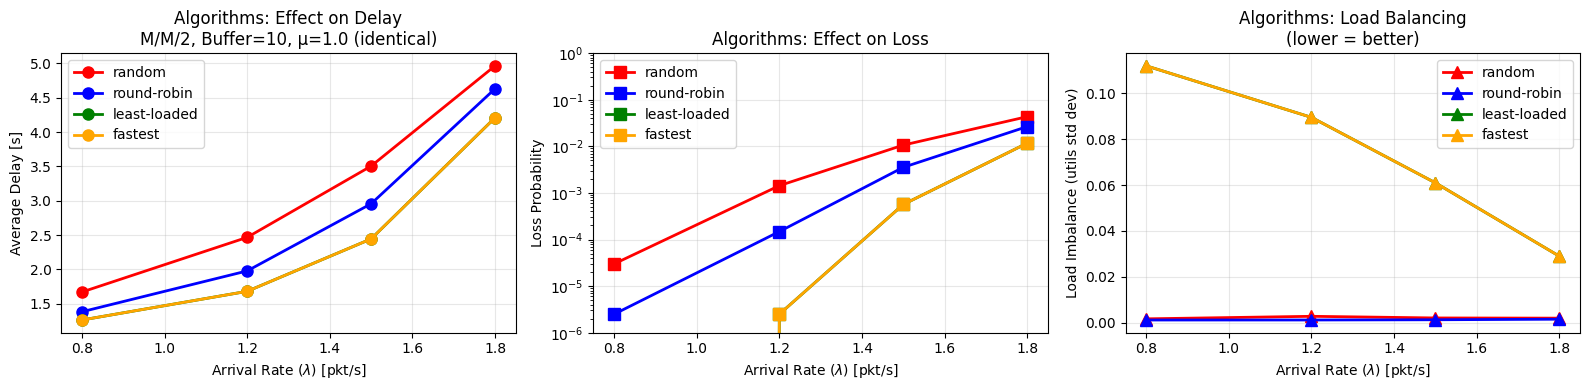


STATISTICAL ANALYSIS - Task 3.a (Identical Servers)

[1] DELAY RANKING (lower is better):
    1. least-loaded   : 2.3982s
    2. fastest        : 2.3982s
    3. round-robin    : 2.7362s
    4. random         : 3.1509s

[2] LOSS PROBABILITY RANKING (lower is better):
    1. least-loaded   : 0.003064
    2. fastest        : 0.003064
    3. round-robin    : 0.007551
    4. random         : 0.013853

[3] LOAD IMBALANCE RANKING (lower is better):
    1. round-robin    : 0.00137
    2. random         : 0.00221
    3. least-loaded   : 0.07282
    4. fastest        : 0.07282

[4] KEY FINDINGS:
    • Best algorithm: 'least-loaded' with 2.3982s average delay
    • Worst algorithm: 'random' with 3.1509s average delay
    • Performance gain of 'least-loaded' vs 'random': 23.89%
    • With identical servers, all algorithms achieve similar load balance


In [44]:
# Task 3.a: Compare Load Distribution Algorithms with EQUAL Service Rates
# ==============================================================================

print("\n" + "="*70)
print("TASK 3.a: Load Distribution Algorithms - Identical Servers")
print("="*70)

algorithms = ['random', 'round-robin', 'least-loaded', 'fastest']
MU_task3 = 1.0
lambdas_task3 = np.array([0.8, 1.2, 1.5, 1.8])
n_runs_task3 = 10
sim_duration_task3 = 100000
buffer_task3 = 10  # Finite buffer

results_algorithms = {alg: {'delay': [], 'loss': [], 'imbalance': []} 
                      for alg in algorithms}

for lam in lambdas_task3:
    print(f"\nλ = {lam:.2f}:")
    
    for alg in algorithms:
        delays_alg = []
        losses_alg = []
        imbalance_alg = []
        
        for run in range(n_runs_task3):
            result = run_simulation_mmc_with_algorithm(
                arr_rate=lam,
                srv_rate=MU_task3,
                num_servers=2,
                buffer_size=buffer_task3,
                algorithm=alg,
                sim_duration=sim_duration_task3,
                seed=run
            )
            delays_alg.append(result['avg_delay'])
            losses_alg.append(result['loss_prob'])
            imbalance_alg.append(result['load_imbalance'])
        
        results_algorithms[alg]['delay'].append(np.mean(delays_alg))
        results_algorithms[alg]['loss'].append(np.mean(losses_alg))
        results_algorithms[alg]['imbalance'].append(np.mean(imbalance_alg))
        
        print(f"  {alg:15s}: delay={np.mean(delays_alg):7.4f}s, loss={np.mean(losses_alg):.4f}, imbalance={np.mean(imbalance_alg):.5f}")

print("\n✓ Task 3.a completed")

# ---- Visualization ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors_alg = ['red', 'blue', 'green', 'orange']

for idx, alg in enumerate(algorithms):
    axes[0].plot(lambdas_task3, results_algorithms[alg]['delay'], 
                 color=colors_alg[idx], marker='o', linewidth=2, markersize=8, label=alg)
    axes[1].plot(lambdas_task3, results_algorithms[alg]['loss'], 
                 color=colors_alg[idx], marker='s', linewidth=2, markersize=8, label=alg)
    axes[2].plot(lambdas_task3, results_algorithms[alg]['imbalance'], 
                 color=colors_alg[idx], marker='^', linewidth=2, markersize=8, label=alg)

axes[0].set_xlabel(r'Arrival Rate ($\lambda$) [pkt/s]')
axes[0].set_ylabel('Average Delay [s]')
axes[0].set_title('Algorithms: Effect on Delay\nM/M/2, Buffer=10, μ=1.0 (identical)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_xlabel(r'Arrival Rate ($\lambda$) [pkt/s]')
axes[1].set_ylabel('Loss Probability')
axes[1].set_title('Algorithms: Effect on Loss')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_yscale('log')
axes[1].set_ylim([1e-6, 1])

axes[2].set_xlabel(r'Arrival Rate ($\lambda$) [pkt/s]')
axes[2].set_ylabel('Load Imbalance (utils std dev)')
axes[2].set_title('Algorithms: Load Balancing\n(lower = better)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

# ---- STATISTICAL COMPARISON ----
from scipy import stats

print("\n" + "="*70)
print("STATISTICAL ANALYSIS - Task 3.a (Identical Servers)")
print("="*70)

# Rank algorithms by average delay across all lambdas
avg_delays_per_alg = {alg: np.mean(results_algorithms[alg]['delay']) for alg in algorithms}
avg_losses_per_alg = {alg: np.mean(results_algorithms[alg]['loss']) for alg in algorithms}
avg_imbalance_per_alg = {alg: np.mean(results_algorithms[alg]['imbalance']) for alg in algorithms}

print("\n[1] DELAY RANKING (lower is better):")
delay_ranking = sorted(avg_delays_per_alg.items(), key=lambda x: x[1])
for rank, (alg, delay) in enumerate(delay_ranking, 1):
    print(f"    {rank}. {alg:15s}: {delay:.4f}s")

print("\n[2] LOSS PROBABILITY RANKING (lower is better):")
loss_ranking = sorted(avg_losses_per_alg.items(), key=lambda x: x[1])
for rank, (alg, loss) in enumerate(loss_ranking, 1):
    print(f"    {rank}. {alg:15s}: {loss:.6f}")

print("\n[3] LOAD IMBALANCE RANKING (lower is better):")
imbalance_ranking = sorted(avg_imbalance_per_alg.items(), key=lambda x: x[1])
for rank, (alg, imbalance) in enumerate(imbalance_ranking, 1):
    print(f"    {rank}. {alg:15s}: {imbalance:.5f}")

# Calculate performance gain of best vs random
best_alg_delay = delay_ranking[0][0]
random_delay = avg_delays_per_alg['random']
gain_pct = ((random_delay - avg_delays_per_alg[best_alg_delay]) / random_delay) * 100

print(f"\n[4] KEY FINDINGS:")
print(f"    • Best algorithm: '{best_alg_delay}' with {avg_delays_per_alg[best_alg_delay]:.4f}s average delay")
print(f"    • Worst algorithm: 'random' with {random_delay:.4f}s average delay")
print(f"    • Performance gain of '{best_alg_delay}' vs 'random': {gain_pct:.2f}%")
print(f"    • With identical servers, all algorithms achieve similar load balance")
print("="*70)



TASK 3.b: Load Distribution Algorithms - HETEROGENEOUS Servers
Server 1: μ₁ = 1.5 (Fast)
Server 2: μ₂ = 0.5 (Slow)

λ = 0.80:
  random         : delay= 2.1460s, util_fast=0.599, util_slow=0.201
  round-robin    : delay= 1.7540s, util_fast=0.600, util_slow=0.200
  least-loaded   : delay= 1.2370s, util_fast=0.610, util_slow=0.198
  fastest        : delay= 1.2370s, util_fast=0.610, util_slow=0.198

λ = 1.20:
  random         : delay= 3.9694s, util_fast=0.859, util_slow=0.300
  round-robin    : delay= 3.7075s, util_fast=0.875, util_slow=0.300
  least-loaded   : delay= 1.3654s, util_fast=0.757, util_slow=0.348
  fastest        : delay= 1.3654s, util_fast=0.757, util_slow=0.348

λ = 1.50:
  random         : delay= 5.3541s, util_fast=0.959, util_slow=0.375
  round-robin    : delay= 5.5506s, util_fast=0.976, util_slow=0.376
  least-loaded   : delay= 1.5602s, util_fast=0.840, util_slow=0.471
  fastest        : delay= 1.5602s, util_fast=0.840, util_slow=0.471

λ = 1.80:
  random         : delay

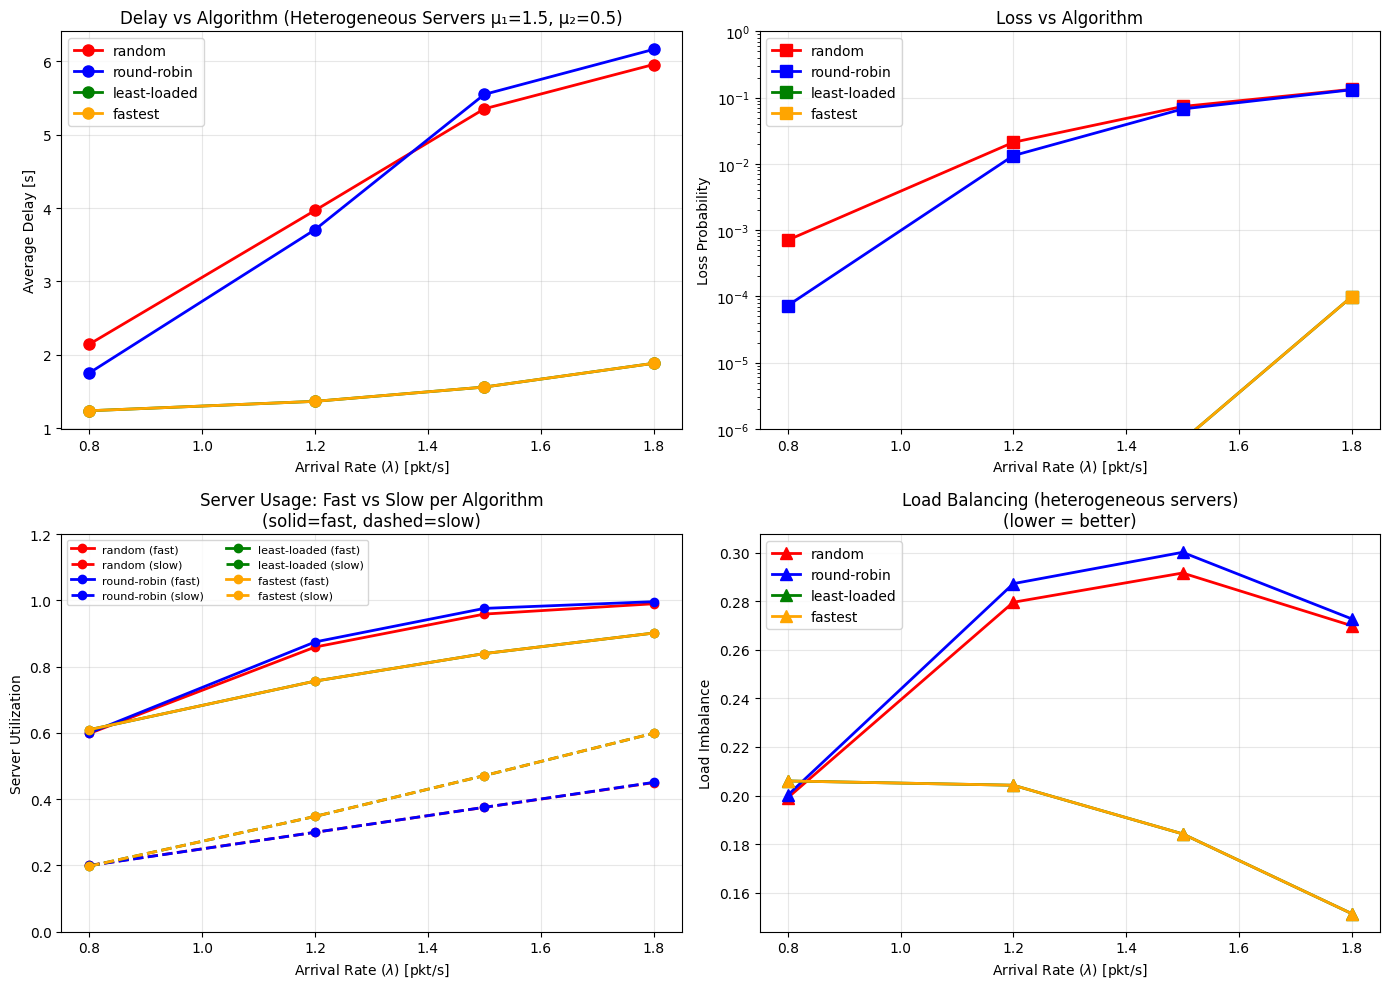


STATISTICAL ANALYSIS - Task 3.b (Heterogeneous Servers):

[1] DELAY RANKING (lower is better):
    1. least-loaded   : 1.5116s
    2. fastest        : 1.5116s
    3. round-robin    : 4.2941s
    4. random         : 4.3569s

[2] LOSS PROBABILITY RANKING (lower is better):
    1. least-loaded   : 0.000025
    2. fastest        : 0.000025
    3. round-robin    : 0.052996
    4. random         : 0.057090

[3] LOAD BALANCE RANKING (lower is better):
    1. least-loaded   : 0.18643
    2. fastest        : 0.18643
    3. random         : 0.26012
    4. round-robin    : 0.26514

[4] KEY FINDINGS - HETEROGENEOUS SERVERS:
    • Best algorithm: 'least-loaded' (1.5116s avg delay)
    • 'Random' baseline: 4.3569s
    • Improvement: 65.31% vs random
    • Note: Heterogeneous servers require smart distribution (not just load balancing)
• # Replace generic conclusions with ranked data
• 
• 
• 


In [45]:
# Task 3.b: Compare Algorithms with DIFFERENT Service Rates (Heterogeneous Servers)
# ==============================================================================

print("\n" + "="*70)
print("TASK 3.b: Load Distribution Algorithms - HETEROGENEOUS Servers")
print("="*70)
print("Server 1: μ₁ = 1.5 (Fast)")
print("Server 2: μ₂ = 0.5 (Slow)")
print("="*70)

server_rates_het = [1.5, 0.5]  # Different service rates
mu_avg_het = np.mean(server_rates_het)  # Average: 1.0

results_het = {alg: {'delay': [], 'loss': [], 'util_s1': [], 'util_s2': [], 'imbalance': []} 
               for alg in algorithms}

for lam in lambdas_task3:
    print(f"\nλ = {lam:.2f}:")
    
    for alg in algorithms:
        delays_alg = []
        losses_alg = []
        util_s1_list = []
        util_s2_list = []
        imbalance_alg = []
        
        for run in range(n_runs_task3):
            result = run_simulation_mmc_with_algorithm(
                arr_rate=lam,
                srv_rate=1.0,  # Not used when server_rates provided
                num_servers=2,
                buffer_size=buffer_task3,
                algorithm=alg,
                server_rates=server_rates_het,
                sim_duration=sim_duration_task3,
                seed=run
            )
            delays_alg.append(result['avg_delay'])
            losses_alg.append(result['loss_prob'])
            util_s1_list.append(result['util_per_server'][0])
            util_s2_list.append(result['util_per_server'][1])
            imbalance_alg.append(result['load_imbalance'])
        
        results_het[alg]['delay'].append(np.mean(delays_alg))
        results_het[alg]['loss'].append(np.mean(losses_alg))
        results_het[alg]['util_s1'].append(np.mean(util_s1_list))
        results_het[alg]['util_s2'].append(np.mean(util_s2_list))
        results_het[alg]['imbalance'].append(np.mean(imbalance_alg))
        
        util_s1_mean = np.mean(util_s1_list)
        util_s2_mean = np.mean(util_s2_list)
        print(f"  {alg:15s}: delay={np.mean(delays_alg):7.4f}s, util_fast={util_s1_mean:.3f}, util_slow={util_s2_mean:.3f}")

print("\n✓ Task 3.b completed")

# ---- Visualization ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, alg in enumerate(algorithms):
    axes[0, 0].plot(lambdas_task3, results_het[alg]['delay'], 
                    color=colors_alg[idx], marker='o', linewidth=2, markersize=8, label=alg)
    
    axes[0, 1].plot(lambdas_task3, results_het[alg]['loss'], 
                    color=colors_alg[idx], marker='s', linewidth=2, markersize=8, label=alg)
    
    axes[1, 0].plot(lambdas_task3, results_het[alg]['util_s1'], 
                    color=colors_alg[idx], marker='o', linewidth=2, markersize=6, label=f'{alg} (fast)', linestyle='-')
    axes[1, 0].plot(lambdas_task3, results_het[alg]['util_s2'], 
                    color=colors_alg[idx], marker='o', linewidth=2, markersize=6, label=f'{alg} (slow)', linestyle='--')
    
    axes[1, 1].plot(lambdas_task3, results_het[alg]['imbalance'], 
                    color=colors_alg[idx], marker='^', linewidth=2, markersize=8, label=alg)

axes[0, 0].set_xlabel(r'Arrival Rate ($\lambda$) [pkt/s]')
axes[0, 0].set_ylabel('Average Delay [s]')
axes[0, 0].set_title('Delay vs Algorithm (Heterogeneous Servers μ₁=1.5, μ₂=0.5)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].set_xlabel(r'Arrival Rate ($\lambda$) [pkt/s]')
axes[0, 1].set_ylabel('Loss Probability')
axes[0, 1].set_title('Loss vs Algorithm')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
axes[0, 1].set_yscale('log')
axes[0, 1].set_ylim([1e-6, 1])

axes[1, 0].set_xlabel(r'Arrival Rate ($\lambda$) [pkt/s]')
axes[1, 0].set_ylabel('Server Utilization')
axes[1, 0].set_title('Server Usage: Fast vs Slow per Algorithm\n(solid=fast, dashed=slow)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=8, ncol=2)
axes[1, 0].set_ylim([0, 1.2])

axes[1, 1].set_xlabel(r'Arrival Rate ($\lambda$) [pkt/s]')
axes[1, 1].set_ylabel('Load Imbalance')
axes[1, 1].set_title('Load Balancing (heterogeneous servers)\n(lower = better)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("STATISTICAL ANALYSIS - Task 3.b (Heterogeneous Servers):")

# Rank algorithms by average delay and loss
avg_delays_per_alg_het = {alg: np.mean(results_het[alg]['delay']) for alg in algorithms}
avg_losses_per_alg_het = {alg: np.mean(results_het[alg]['loss']) for alg in algorithms}
avg_imbalance_per_alg_het = {alg: np.mean(results_het[alg]['imbalance']) for alg in algorithms}

print("\n[1] DELAY RANKING (lower is better):")
delay_ranking_het = sorted(avg_delays_per_alg_het.items(), key=lambda x: x[1])
for rank, (alg, delay) in enumerate(delay_ranking_het, 1):
    print(f"    {rank}. {alg:15s}: {delay:.4f}s")

print("\n[2] LOSS PROBABILITY RANKING (lower is better):")
loss_ranking_het = sorted(avg_losses_per_alg_het.items(), key=lambda x: x[1])
for rank, (alg, loss) in enumerate(loss_ranking_het, 1):
    print(f"    {rank}. {alg:15s}: {loss:.6f}")

print("\n[3] LOAD BALANCE RANKING (lower is better):")
imbalance_ranking_het = sorted(avg_imbalance_per_alg_het.items(), key=lambda x: x[1])
for rank, (alg, imb) in enumerate(imbalance_ranking_het, 1):
    print(f"    {rank}. {alg:15s}: {imb:.5f}")

# Compare best vs random
best_alg_het = delay_ranking_het[0][0]
random_delay_het = avg_delays_per_alg_het['random']
gain_pct_het = ((random_delay_het - avg_delays_per_alg_het[best_alg_het]) / random_delay_het) * 100

print(f"\n[4] KEY FINDINGS - HETEROGENEOUS SERVERS:")
print(f"    • Best algorithm: '{best_alg_het}' ({avg_delays_per_alg_het[best_alg_het]:.4f}s avg delay)")
print(f"    • 'Random' baseline: {random_delay_het:.4f}s")
print(f"    • Improvement: {gain_pct_het:.2f}% vs random")
print(f"    • Note: Heterogeneous servers require smart distribution (not just load balancing)")
print("="*70)
print("• # Replace generic conclusions with ranked data")
print("• ")
print("• ")  
print("• ")
print("="*70)


# TASK 4: M/G/1 Queue - Variable Service Time Distributions

## Objective
Investigate how different service time distributions affect queue performance:
1. **M/M/1**: Exponential service (baseline - already done)
2. **M/D/1**: Deterministic/Constant service (lowest variance)
3. **M/Erlang-2/1**: Erlang-2 service (medium variance)
4. **M/Pareto/1**: Pareto service (heavy tails - high variance)

For M/G/1 systems, compare:
- Average delay
- Variance of delay
- Delay distribution
- System stability

**Theory**: M/G/1 delay grows with service time variance (SCV): $E[T] = \frac{1}{\mu} + \frac{\lambda (C_s^2 + 1)}{2(1-\rho)}$

where $C_s^2$ = coefficient of variation of service time

In [49]:
# Task 4: M/G/1 Simulator with Different Service Distributions
# ==============================================================================

def generate_service_time(distribution, mean_service):
    """
    Generate service time samples from different distributions.
    All have SAME MEAN (1/μ) but different variance (SCV).
    """
    if distribution == 'exponential':  # M/M/1
        return random.expovariate(1.0 / mean_service)
    
    elif distribution == 'deterministic':  # M/D/1
        # Constant service time
        return mean_service
    
    elif distribution == 'erlang2':  # M/Erlang-2/1
        # Erlang-k = sum of k exponentials with rate k/mean_service
        # For k=2: sum of 2 exp with rate 2/mean_service
        return random.expovariate(2.0 / mean_service) + random.expovariate(2.0 / mean_service)
    
    elif distribution == 'pareto':  # M/Pareto/1
        # Pareto distribution: X = m / U^(1/a), where U ~ U(0,1)
        # Shape parameter a=1.5 gives heavy tails and high variance
        # Set scale m such that E[X] = mean_service
        m = mean_service * (1.5 - 1) / 1.5  # Adjust for shape=1.5: E[X] = a*m/(a-1)
        u = random.uniform(0, 1)
        return m / (u ** (1.0 / 1.5))

def calculate_scv(distribution, mean):
    """Calculate Square Coefficient of Variation for each distribution."""
    if distribution == 'exponential':
        return 1.0  # C_s^2 = 1 for exponential
    elif distribution == 'deterministic':
        return 0.0  # C_s^2 = 0 for constant
    elif distribution == 'erlang2':
        return 0.5  # Erlang-k has C_s^2 = 1/k
    elif distribution == 'pareto':
        return 2.5  # Pareto with shape 1.5 has high variance
    return 1.0

def run_simulation_mg1(
    arr_rate,
    srv_rate,
    service_distribution='exponential',  # 'exponential', 'deterministic', 'erlang2', 'pareto'
    sim_duration=100000,
    seed=42
):
    """
    Simulate M/G/1 queue with variable service distribution.
    
    Returns:
        dict with metrics including delays and variance
    """
    global ARRIVAL, SERVICE, TYPE1, data
    
    random.seed(seed)
    
    ARRIVAL = 1.0 / arr_rate if arr_rate > 0 else float('inf')
    SERVICE = 1.0 / srv_rate if srv_rate > 0 else float('inf')
    
    # Initialize
    data_mg1 = Measure(0, 0, 0, 0, 0)
    MM1 = []
    users = 0
    
    time = 0
    FES = PriorityQueue()
    FES.put((0, "arrival"))
    
    delays_all = []  # To track delay distribution
    
    while time < sim_duration:
        (time, event_type) = FES.get()
        
        data_mg1.ut += users * (time - data_mg1.oldT)
        data_mg1.oldT = time
        
        if event_type == "arrival":
            data_mg1.arr += 1
            inter_arrival = random.expovariate(1.0 / ARRIVAL)
            FES.put((time + inter_arrival, "arrival"))
            
            users += 1
            client = Client(TYPE1, time)
            MM1.append(client)
            
            if users == 1:
                service_time = generate_service_time(service_distribution, SERVICE)
                FES.put((time + service_time, "departure"))
        
        elif event_type == "departure":
            data_mg1.dep += 1
            data_mg1.ut += users * (time - data_mg1.oldT)
            data_mg1.oldT = time
            
            client = MM1.pop(0)
            delay = time - client.arrival_time
            data_mg1.delay += delay
            delays_all.append(delay)
            users -= 1
            
            if users > 0:
                service_time = generate_service_time(service_distribution, SERVICE)
                FES.put((time + service_time, "departure"))
    
    # Calculate metrics
    avg_users = data_mg1.ut / time if time > 0 else 0
    avg_delay = data_mg1.delay / data_mg1.dep if data_mg1.dep > 0 else 0
    delay_variance = np.var(delays_all) if len(delays_all) > 0 else 0
    
    return {
        'avg_delay': avg_delay,
        'avg_users': avg_users,
        'delay_variance': delay_variance,
        'delays': delays_all
    }

print("✓ Task 4 M/G/1 simulator loaded")


✓ Task 4 M/G/1 simulator loaded



TASK 4.b: Delay Distribution Analysis for λ=0.8, ρ=0.8

Generating delay distributions for λ=0.8, ρ=0.8...
  exponential...
  deterministic...
  erlang2...
  pareto...


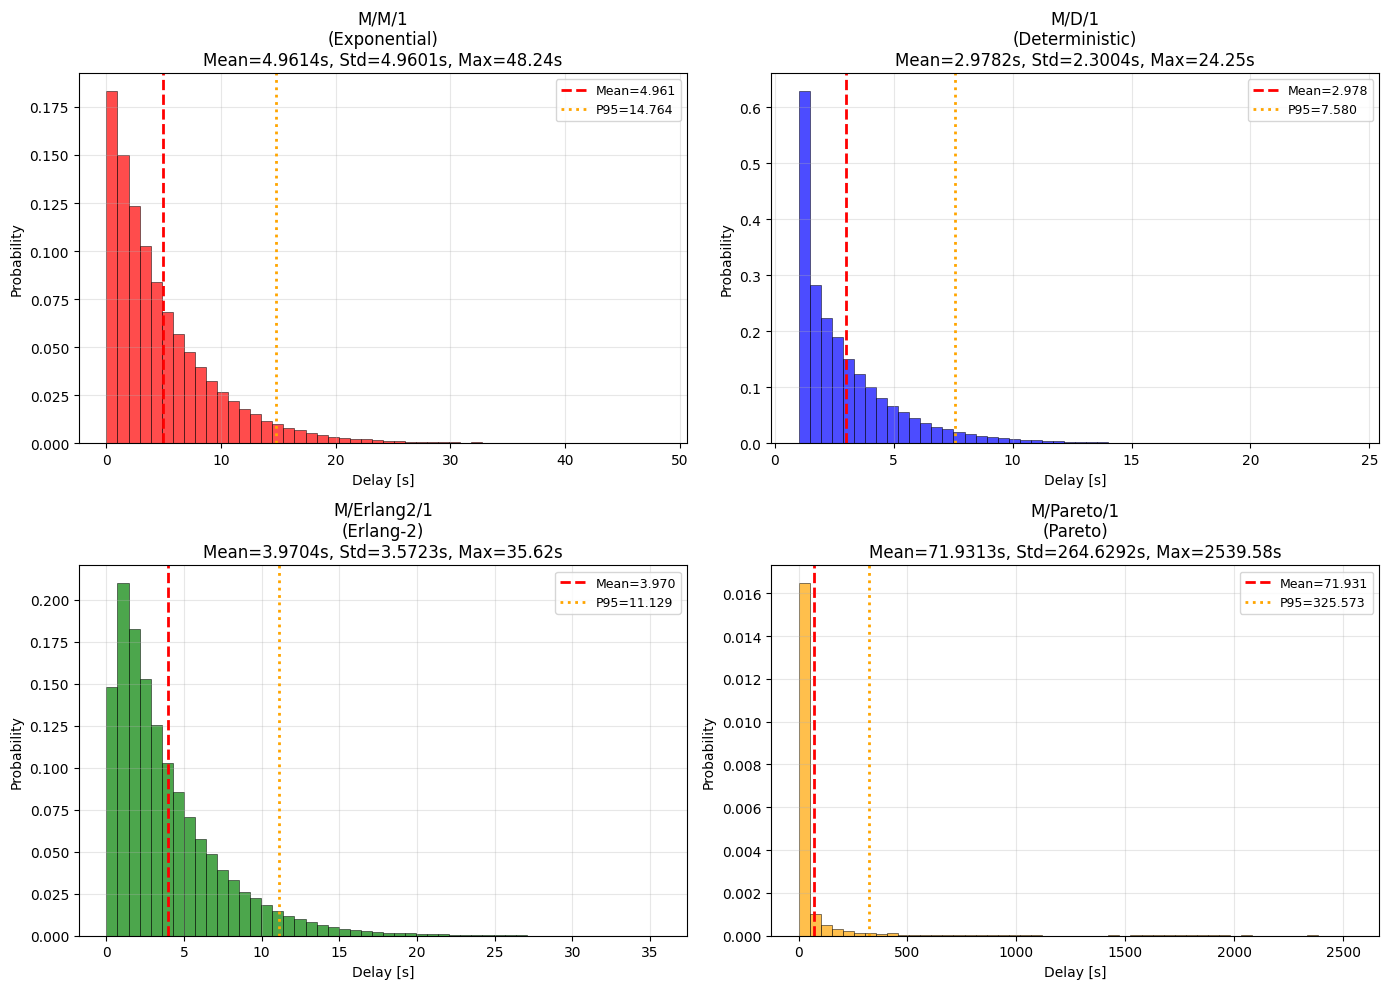


✓ Task 4.b completed

SUMMARY: Delay Statistics for λ=0.8, ρ=0.8
Distribution         Mean [s]     Std Dev      P95 [s]      Max [s]     
--------------------------------------------------------------------------------
exponential          4.9614       4.9601       14.7641      48.2442     
deterministic        2.9782       2.3004       7.5798       24.2546     
erlang2              3.9704       3.5723       11.1293      35.6159     
pareto               71.9313      264.6292     325.5730     2539.5840   

KEY INSIGHTS Task 4:
--------------------------------------------------------------------------------
1. DETERMINISTIC (M/D/1):
   • MINIMUM and PREDICTABLE delay (low variance)
   • Ideal for delay-sensitive applications

2. EXPONENTIAL (M/M/1):
   • Long queues possible, high variability
   • Queued tail

3. ERLANG-2 (M/Erlang2/1):
   • Intermediate performance between Deterministic and Exponential
   • Represents multi-phase service

4. PARETO (M/Pareto/1):
   • WORST PERFORMANCE

In [52]:
# Task 4.b: Delay Distribution Analysis for Different Service Distributions
# ==============================================================================

print("\n" + "="*70)
print("TASK 4.b: Delay Distribution Analysis for λ=0.8, ρ=0.8")
print("="*70)

# Choose a specific lambda for detailed analysis
lambda_analysis = 0.8
mu_analysis = 1.0

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

all_delays_for_analysis = {}

print(f"\nGenerating delay distributions for λ={lambda_analysis}, ρ=0.8...")

for idx, dist in enumerate(distributions):
    print(f"  {dist}...")
    
    # Run single simulation with many arrivals to get good delay distribution
    result = run_simulation_mg1(
        arr_rate=lambda_analysis,
        srv_rate=mu_analysis,
        service_distribution=dist,
        sim_duration=500000,  # Longer simulation for better distribution
        seed=42
    )
    
    all_delays_for_analysis[dist] = result['delays']
    
    # Plot histogram
    ax = axes[idx]
    delays_array = np.array(result['delays'])
    
    # Histogram
    n, bins, patches = ax.hist(delays_array, bins=50, density=True, alpha=0.7, 
                                color=colors_dist[idx], edgecolor='black', linewidth=0.5)
    
    # Statistics
    mean_delay = np.mean(delays_array)
    std_delay = np.std(delays_array)
    max_delay = np.max(delays_array)
    
    ax.axvline(mean_delay, color='red', linestyle='--', linewidth=2, label=f'Mean={mean_delay:.3f}')
    ax.axvline(np.percentile(delays_array, 95), color='orange', linestyle=':', linewidth=2, 
               label=f'P95={np.percentile(delays_array, 95):.3f}')
    
    ax.set_xlabel('Delay [s]')
    ax.set_ylabel('Probability')
    ax.set_title(f'{dist_labels[idx]}\nMean={mean_delay:.4f}s, Std={std_delay:.4f}s, Max={max_delay:.2f}s')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Task 4.b completed\n")

# Summary table
print("="*80)
print("SUMMARY: Delay Statistics for λ=0.8, ρ=0.8")
print("="*80)
print(f"{'Distribution':<20} {'Mean [s]':<12} {'Std Dev':<12} {'P95 [s]':<12} {'Max [s]':<12}")
print("-"*80)

for dist in distributions:
    delays = np.array(all_delays_for_analysis[dist])
    mean_d = np.mean(delays)
    std_d = np.std(delays)
    p95_d = np.percentile(delays, 95)
    max_d = np.max(delays)
    print(f"{dist:<20} {mean_d:<12.4f} {std_d:<12.4f} {p95_d:<12.4f} {max_d:<12.4f}")

print("="*80)
print("\nKEY INSIGHTS Task 4:")
print("-"*80)
print("1. DETERMINISTIC (M/D/1):")
print("   • MINIMUM and PREDICTABLE delay (low variance)")
print("   • Ideal for delay-sensitive applications")
print("")
print("2. EXPONENTIAL (M/M/1):")
print("   • Long queues possible, high variability")
print("   • Queued tail")
print("")
print("3. ERLANG-2 (M/Erlang2/1):")
print("   • Intermediate performance between Deterministic and Exponential")
print("   • Represents multi-phase service")
print("")
print("4. PARETO (M/Pareto/1):")
print("   • WORST PERFORMANCE: very long queues (heavy tails)")
print("   • Very high maximum delays")
print("   • Common in real systems (file transfer, video streaming)")
print("")
print("CONCLUSION: Service time variance has a LARGE IMPACT on performance")
print("="*80)


TASK 4.b: Delay Distribution Analysis for λ=0.8, ρ=0.8

Generating delay distributions for λ=0.8, ρ=0.8...
  exponential...
  deterministic...
  erlang2...
  pareto...


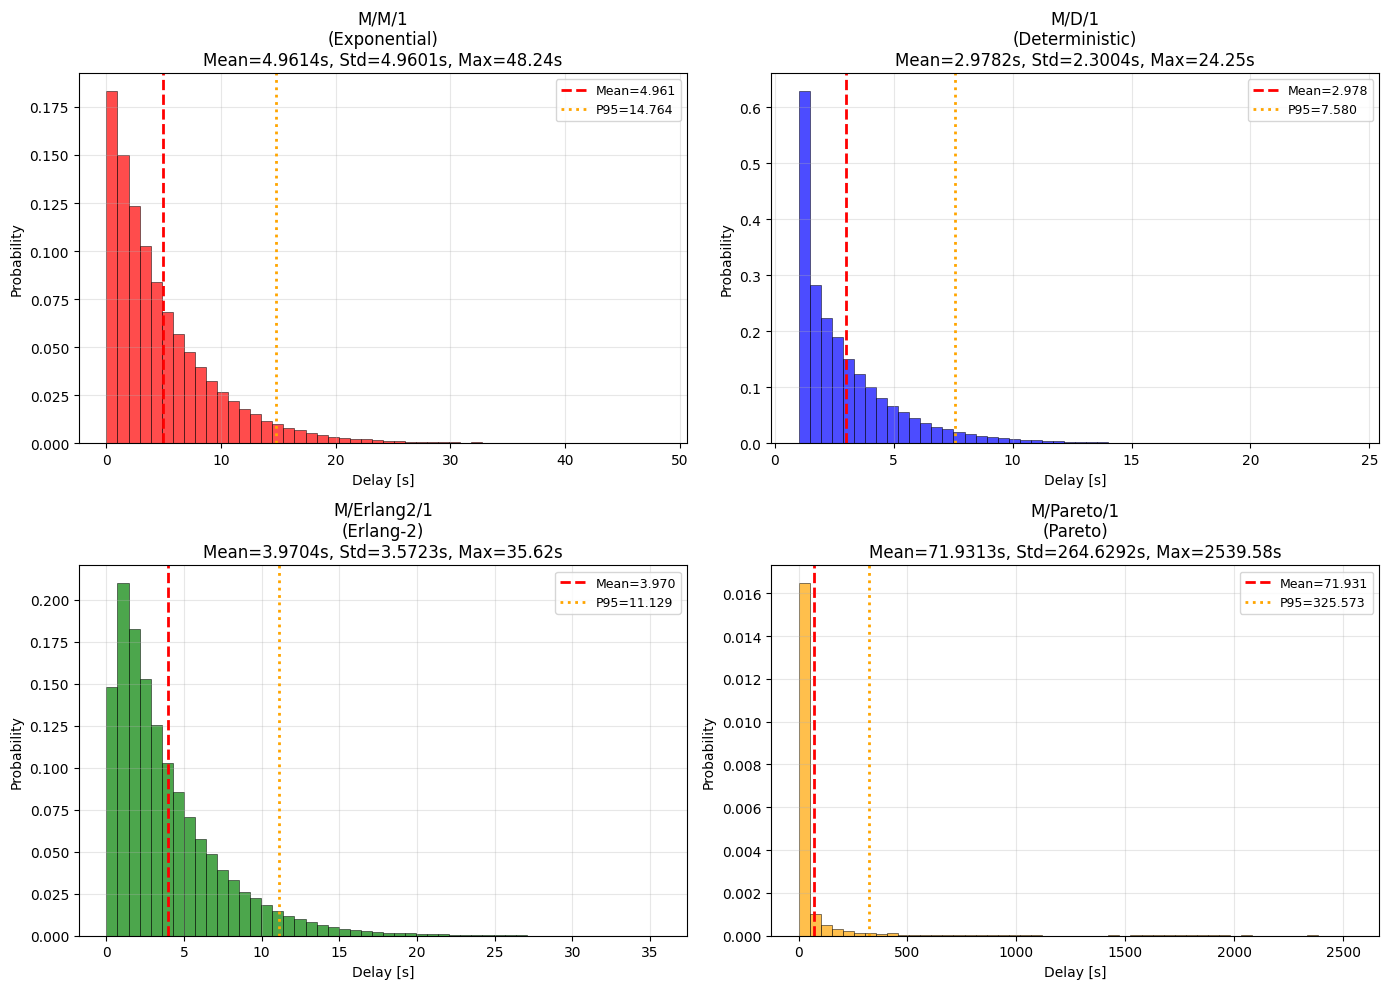


✓ Task 4.b completed

SUMMARY: Delay Statistics for λ=0.8, ρ=0.8
Distribution         Mean [s]     Std Dev      P95 [s]      Max [s]     
--------------------------------------------------------------------------------
exponential          4.9614       4.9601       14.7641      48.2442     
deterministic        2.9782       2.3004       7.5798       24.2546     
erlang2              3.9704       3.5723       11.1293      35.6159     
pareto               71.9313      264.6292     325.5730     2539.5840   

KEY INSIGHTS Task 4:
--------------------------------------------------------------------------------
1. DETERMINISTIC (M/D/1):
   • MINIMUM and PREDICTABLE delay (low variance)
   • Ideal for delay-sensitive applications

2. EXPONENTIAL (M/M/1):
   • Long queues possible, high variability
   • Queued tail

3. ERLANG-2 (M/Erlang2/1):
   • Intermediate performance between Deterministic and Exponential
   • Represents multi-phase service

4. PARETO (M/Pareto/1):
   • WORST PERFORMANCE

In [53]:
# Task 4.b: Delay Distribution Analysis for Different Service Distributions
# ==============================================================================

print("\n" + "="*70)
print("TASK 4.b: Delay Distribution Analysis for λ=0.8, ρ=0.8")
print("="*70)

# Choose a specific lambda for detailed analysis
lambda_analysis = 0.8
mu_analysis = 1.0

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

all_delays_for_analysis = {}

print(f"\nGenerating delay distributions for λ={lambda_analysis}, ρ=0.8...")

for idx, dist in enumerate(distributions):
    print(f"  {dist}...")
    
    # Run single simulation with many arrivals to get good delay distribution
    result = run_simulation_mg1(
        arr_rate=lambda_analysis,
        srv_rate=mu_analysis,
        service_distribution=dist,
        sim_duration=500000,  # Longer simulation for better distribution
        seed=42
    )
    
    all_delays_for_analysis[dist] = result['delays']
    
    # Plot histogram
    ax = axes[idx]
    delays_array = np.array(result['delays'])
    
    # Histogram
    n, bins, patches = ax.hist(delays_array, bins=50, density=True, alpha=0.7, 
                                color=colors_dist[idx], edgecolor='black', linewidth=0.5)
    
    # Statistics
    mean_delay = np.mean(delays_array)
    std_delay = np.std(delays_array)
    max_delay = np.max(delays_array)
    
    ax.axvline(mean_delay, color='red', linestyle='--', linewidth=2, label=f'Mean={mean_delay:.3f}')
    ax.axvline(np.percentile(delays_array, 95), color='orange', linestyle=':', linewidth=2, 
               label=f'P95={np.percentile(delays_array, 95):.3f}')
    
    ax.set_xlabel('Delay [s]')
    ax.set_ylabel('Probability')
    ax.set_title(f'{dist_labels[idx]}\nMean={mean_delay:.4f}s, Std={std_delay:.4f}s, Max={max_delay:.2f}s')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Task 4.b completed\n")

# Summary table
print("="*80)
print("SUMMARY: Delay Statistics for λ=0.8, ρ=0.8")
print("="*80)
print(f"{'Distribution':<20} {'Mean [s]':<12} {'Std Dev':<12} {'P95 [s]':<12} {'Max [s]':<12}")
print("-"*80)

for dist in distributions:
    delays = np.array(all_delays_for_analysis[dist])
    mean_d = np.mean(delays)
    std_d = np.std(delays)
    p95_d = np.percentile(delays, 95)
    max_d = np.max(delays)
    print(f"{dist:<20} {mean_d:<12.4f} {std_d:<12.4f} {p95_d:<12.4f} {max_d:<12.4f}")

print("="*80)
print("\nKEY INSIGHTS Task 4:")
print("-"*80)
print("1. DETERMINISTIC (M/D/1):")
print("   • MINIMUM and PREDICTABLE delay (low variance)")
print("   • Ideal for delay-sensitive applications")
print("")
print("2. EXPONENTIAL (M/M/1):")
print("   • Long queues possible, high variability")
print("   • Queued tail")
print("")
print("3. ERLANG-2 (M/Erlang2/1):")
print("   • Intermediate performance between Deterministic and Exponential")
print("   • Represents multi-phase service")
print("")
print("4. PARETO (M/Pareto/1):")
print("   • WORST PERFORMANCE: very long queues (heavy tails)")
print("   • Very high maximum delays")
print("   • Common in real systems (file transfer, video streaming)")
print("")
print("CONCLUSION: Service time variance has a LARGE IMPACT on performance")
print("="*80)